In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from llms.llm_ochestrator import LLMOchestrator
config_name = "gpt2-small"
ochestrator = LLMOchestrator(config_name, "basic")

ochestrator.model_config

{'vocab_size': 50257,
 'drop_rate': 0.1,
 'qkv_bias': False,
 'model_name': 'gpt2-small',
 'model_size': '124M',
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12,
 'context_length': 256}

In [ ]:
# ochestrator.load_weight()

In [3]:
model_path = "./trained_models/gpt2_small_(124M)_state_and_optimizer.pth"
ochestrator.load_model(model_path)

In [ ]:
# model_path = "./trained_models/gpt2_small_(124M)_state_and_optimizer.pth"
# ochestrator.save_model(model_path)

In [4]:
train_loader, validation_loader, test_loader = ochestrator.create_plantext_dataloader("./training_data/pg7213.txt")
print(f"Train loader length:{len(train_loader)}")
input, target = next(iter(train_loader))
print(f"Train loader input shape: {input.shape}")
print(f"Train loader target shape: {target.shape}")
print(f"Validation loader length:{len(validation_loader)}")
input, target = next(iter(validation_loader))
print(f"Validation loader input shape: {input.shape}")
print(f"Validation loader target shape: {target.shape}")
print(f"Test loader length:{len(test_loader)}")
input, target = next(iter(test_loader))
print(f"Test loader input shape: {input.shape}")
print(f"Test loader target shape: {target.shape}")

Train loader length:87
Train loader input shape: torch.Size([4, 256])
Train loader target shape: torch.Size([4, 256])
Validation loader length:24
Validation loader input shape: torch.Size([4, 256])
Validation loader target shape: torch.Size([4, 256])
Test loader length:13
Test loader input shape: torch.Size([4, 256])
Test loader target shape: torch.Size([4, 256])


In [ ]:
# train_losses, val_losses, tokens_seen = ochestrator.train_model_by_plantext(num_epochs=10, eval_freq=5, eval_iter=5, 
#                                     start_context="Volunteers and financial support", train_loader=train_loader, 
#                                     validation_loader=validation_loader)

# print(f"train_losses:{train_losses}")
# print(f"val_losses:{val_losses}")
# print(f"track_tokens_seen:{track_tokens_seen}")

In [5]:
import torch
torch.manual_seed(123)
ochestrator.train_model_by_plantext(num_epochs=10, 
                                    start_context="Every effort moves you", 
                                    file_path="./training_data/pg79500.txt", batch_size=2)

Ep 1 (Step 000000): Train loss 0.042, Val loss 9.217
Ep 1 (Step 000005): Train loss 0.065, Val loss 9.172
Ep 1 (Step 000010): Train loss 0.068, Val loss 9.280
Ep 1 (Step 000015): Train loss 0.075, Val loss 9.346
Ep 1 (Step 000020): Train loss 0.060, Val loss 9.144
Ep 1 (Step 000025): Train loss 0.078, Val loss 9.135
Ep 1 (Step 000030): Train loss 0.094, Val loss 9.122
Every effort moves you see,   And worth her weight in gold, man.”  “Young man,” he said, “I’m not so old,   But I might be her father; I have a
Ep 2 (Step 000035): Train loss 0.116, Val loss 9.274
Ep 2 (Step 000040): Train loss 0.177, Val loss 9.141
Ep 2 (Step 000045): Train loss 0.105, Val loss 9.222
Ep 2 (Step 000050): Train loss 0.072, Val loss 9.493
Ep 2 (Step 000055): Train loss 0.087, Val loss 9.414
Ep 2 (Step 000060): Train loss 0.120, Val loss 9.207
Every effort moves you see,   I mean, if you care about me, For now I am through with my boyhood   For the love of sweet Maggie McGee.  “And Maggie, see, here is a pla

([0.04240233460441232,
  0.06534457579255104,
  0.06760218814015388,
  0.0745743066072464,
  0.05979786552488804,
  0.07832949347794056,
  0.09409454464912415,
  0.11593226715922356,
  0.1768406979739666,
  0.10489905178546906,
  0.07209978997707367,
  0.08684665337204933,
  0.11967646032571792,
  0.102605901658535,
  0.09194793105125428,
  0.10707376599311828,
  0.1760258600115776,
  0.09205544516444206,
  0.10164515152573586,
  0.08260796293616295,
  0.054069819301366805,
  0.07865697965025902,
  0.08671864420175553,
  0.06916205659508705,
  0.05555134601891041,
  0.052516961470246315,
  0.08148431107401848,
  0.07461461871862411,
  0.07800914496183395,
  0.0949299618601799,
  0.0783353567123413,
  0.0808065228164196,
  0.0635472446680069,
  0.09936909452080726,
  0.05481172166764736,
  0.03174277506768704,
  0.046466441452503206,
  0.04727858304977417,
  0.04222315102815628,
  0.02324087209999561,
  0.07580436579883099,
  0.05325463861227035,
  0.03218492455780506,
  0.0198438586667

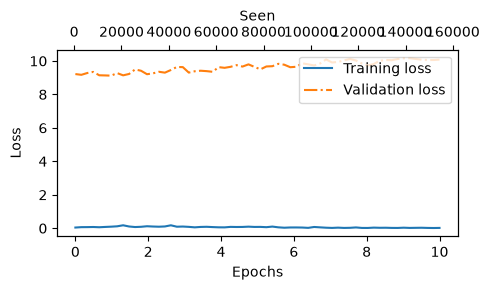

In [6]:
ochestrator.plot_losses()

In [ ]:
import torch
torch.manual_seed(123)
text = ochestrator.generate_text("Every effort moves you", max_new_tokens=15)
print(text)